In [22]:
import numpy as np

prices = np.array([
    [100, 108, 103, 115, 110, 119, 125, 121, 130, 127, 135, 140],  # Stock A
    [200, 195, 210, 205, 220, 215, 225, 230, 222, 235, 240, 238]   # Stock B
])

# (a) Monthly simple returns — shape (2, 11)
returns = (prices[:, 1:] - prices[:, :-1]) / prices[:, :-1]
print("Monthly Returns (shape", returns.shape, "):")
print(np.round(returns, 4))

# (b) Annualised mean and std
monthly_mean = returns.mean(axis=1)
monthly_std  = returns.std(axis=1, ddof=1)

ann_mean = monthly_mean * 12
ann_std  = monthly_std  * np.sqrt(12)

print("\nAnnualised Mean Return — A: {:.2%}, B: {:.2%}".format(*ann_mean))
print("Annualised Std Dev     — A: {:.2%}, B: {:.2%}".format(*ann_std))

# (c) 2×2 sample covariance matrix
cov_matrix = np.cov(returns)          # ddof=1 by default
rho = np.corrcoef(returns)[0, 1]
manual_offdiag = rho * monthly_std[0] * monthly_std[1]

print("\nCovariance Matrix:\n", np.round(cov_matrix, 6))
print(f"Off-diagonal from np.cov   : {cov_matrix[0,1]:.6f}")
print(f"ρ · σ_A · σ_B (manual)     : {manual_offdiag:.6f}")
print("Match:", np.isclose(cov_matrix[0,1], manual_offdiag))

Monthly Returns (shape (2, 11) ):
[[ 0.08   -0.0463  0.1165 -0.0435  0.0818  0.0504 -0.032   0.0744 -0.0231
   0.063   0.037 ]
 [-0.025   0.0769 -0.0238  0.0732 -0.0227  0.0465  0.0222 -0.0348  0.0586
   0.0213 -0.0083]]

Annualised Mean Return — A: 39.09%, B: 20.07%
Annualised Std Dev     — A: 20.20%, B: 14.58%

Covariance Matrix:
 [[ 0.0034   -0.002064]
 [-0.002064  0.001772]]
Off-diagonal from np.cov   : -0.002064
ρ · σ_A · σ_B (manual)     : -0.002064
Match: True


In [23]:
# Parameters from Q6
mu = np.array([0.15, 0.08, 0.05])
Sigma = np.array([
    [0.0625,  0.0120,  0.0010 ],
    [0.0120,  0.0144,  0.00096],
    [0.0010,  0.00096, 0.0016 ]
])
Rf = 0.04

# (a) Equal-weight portfolio
w_eq = np.array([1/3, 1/3, 1/3])
E_rp_eq  = w_eq @ mu
var_p_eq = w_eq @ Sigma @ w_eq
sig_p_eq = np.sqrt(var_p_eq)

print(f"Equal-weight E[Rp]  = {E_rp_eq:.4%}")
print(f"Equal-weight σp     = {sig_p_eq:.4%}")

# (b) 10,000 random portfolios via Dirichlet
np.random.seed(42)
W = np.random.dirichlet(np.ones(3), size=10_000)   # shape (10000, 3)

E_rp_all  = W @ mu                                  # (10000,)
var_p_all = np.einsum('ij,jk,ik->i', W, Sigma, W)  # vectorised w'Σw
sig_p_all = np.sqrt(var_p_all)                      # (10000,)

# (c) Sharpe Ratios — fully vectorised, no loops
sharpes = (E_rp_all - Rf) / sig_p_all

best_idx = np.argmax(sharpes)
print(f"\nMax Sharpe Ratio     : {sharpes[best_idx]:.4f}")
print(f"Weights at max Sharpe: {np.round(W[best_idx], 4)}")
print(f"E[Rp]                : {E_rp_all[best_idx]:.4%}")
print(f"σp                   : {sig_p_all[best_idx]:.4%}")

Equal-weight E[Rp]  = 9.3333%
Equal-weight σp     = 10.8740%

Max Sharpe Ratio     : 0.5053
Weights at max Sharpe: [0.2034 0.1715 0.6251]
E[Rp]                : 7.5488%
σp                   : 7.0232%


In [24]:
mu1, sig1, mu2, sig2, w1 = 0.12, 0.20, 0.06, 0.10, 0.6
w2 = 1 - w1
Rf = 0.04

# (a) σp over 200 correlation values — no loops
rho_arr = np.linspace(-1, 1, 200)                         # shape (200,)
var_p   = (w1*sig1)**2 + (w2*sig2)**2 + 2*w1*w2*rho_arr*sig1*sig2
sig_p   = np.sqrt(var_p)                                  # shape (200,)

# (b) Minimum σp
min_idx   = np.argmin(sig_p)
rho_min   = rho_arr[min_idx]
sigp_min  = sig_p[min_idx]
print(f"ρ at minimum σp : {rho_min:.4f}")
print(f"Minimum σp      : {sigp_min:.4%}")

# (c) Analytical verification
# σ²p = (w1σ1)² + (w2σ2)² + 2·w1·w2·ρ·σ1·σ2
# d(σ²p)/dρ = 2·w1·w2·σ1·σ2  > 0  always (since w1,w2,σ1,σ2 > 0)
# σ²p is strictly INCREASING in ρ → minimum is at ρ = −1  (boundary)
print("\nAnalytical check: d(σ²p)/dρ = 2·w1·w2·σ1·σ2 =",
      round(2*w1*w2*sig1*sig2, 6), "> 0 for all ρ")
print("→ σp is strictly increasing in ρ; minimum always at ρ = −1.")
print(f"σp at ρ=−1: {np.sqrt((w1*sig1 - w2*sig2)**2):.4%}")

ρ at minimum σp : -1.0000
Minimum σp      : 8.0000%

Analytical check: d(σ²p)/dρ = 2·w1·w2·σ1·σ2 = 0.0096 > 0 for all ρ
→ σp is strictly increasing in ρ; minimum always at ρ = −1.
σp at ρ=−1: 8.0000%


In [25]:
import pandas as pd

# --- Setup (given) ---
np.random.seed(0)
dates = pd.date_range('2023-01-02', periods=52, freq='W-MON')
mu_weekly  = np.array([0.003, 0.002, 0.001, 0.0015])
sig_weekly = np.array([0.04,  0.03,  0.02,  0.025 ])
returns_sim = np.random.normal(mu_weekly, sig_weekly, (52, 4))
prices_sim  = 100 * np.cumprod(1 + returns_sim, axis=0)
df = pd.DataFrame(prices_sim, index=dates,
                  columns=['AAPL', 'MSFT', 'GOOGL', 'AMZN'])

# (a) Weekly simple returns
df_ret = df.pct_change().dropna()
print("First 3 rows of returns:")
print(df_ret.head(3))
print("Shape:", df_ret.shape)   # Expected: (51, 4)

# (b) Descriptive statistics
desc = df_ret.describe()
print("\n", desc)
print("Highest mean return :", desc.loc['mean'].idxmax())
print("Highest std dev     :", desc.loc['std'].idxmax())

# (c) Annualised Sharpe Ratio — no loops
Rf_annual   = 0.02
Rf_weekly   = Rf_annual / 52

ann_mean_ret = df_ret.mean() * 52
ann_std_ret  = df_ret.std()  * np.sqrt(52)
sharpe_ann   = (ann_mean_ret - Rf_annual) / ann_std_ret

print("\nAnnualised Sharpe Ratios:")
print(sharpe_ann.round(4))

First 3 rows of returns:
                AAPL      MSFT     GOOGL      AMZN
2023-01-09  0.077702 -0.027318  0.020002 -0.002284
2023-01-16 -0.001129  0.014318  0.003881  0.037857
2023-01-23  0.033442  0.005650  0.009877  0.009842
Shape: (51, 4)

             AAPL       MSFT      GOOGL       AMZN
count  51.000000  51.000000  51.000000  51.000000
mean    0.005603   0.002192  -0.000887   0.006094
std     0.045641   0.032819   0.017055   0.022948
min    -0.099120  -0.057424  -0.033125  -0.054085
25%    -0.030293  -0.025056  -0.013135  -0.006813
50%     0.001429  -0.002650  -0.000365   0.009468
75%     0.039082   0.028178   0.009462   0.020051
max     0.098326   0.060309   0.044265   0.050269
Highest mean return : AMZN
Highest std dev     : AAPL

Annualised Sharpe Ratios:
AAPL     0.8245
MSFT     0.3971
GOOGL   -0.5376
AMZN     1.7940
dtype: float64


In [26]:
# Continuing from Q13 — df_ret already defined

# (a) Correlation matrix
corr_matrix = df_ret.corr()
print("Correlation Matrix:")
print(corr_matrix.round(4))

# Find lowest off-diagonal correlation
corr_unstacked = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
).stack()
min_pair = corr_unstacked.idxmin()
print(f"\nLowest correlation pair: {min_pair}  ({corr_unstacked.min():.4f})")

# (b) Equal-weight portfolio return series
weights = pd.Series([0.25, 0.25, 0.25, 0.25],
                    index=['AAPL', 'MSFT', 'GOOGL', 'AMZN'])
port_returns = df_ret.dot(weights)
print("\nPortfolio return series (first 5):")
print(port_returns.head())

# (c) Resample to monthly
def compound_returns(r):
    return (1 + r).prod() - 1

monthly_port = port_returns.resample('ME').apply(compound_returns)
print("\nMonthly portfolio returns:")
print(monthly_port.round(4))
print(f"\nMean monthly return : {monthly_port.mean():.4%}")
print(f"Std  monthly return : {monthly_port.std():.4%}")

Correlation Matrix:
         AAPL    MSFT   GOOGL    AMZN
AAPL   1.0000 -0.0753  0.1907  0.0601
MSFT  -0.0753  1.0000  0.2873  0.0695
GOOGL  0.1907  0.2873  1.0000 -0.0013
AMZN   0.0601  0.0695 -0.0013  1.0000

Lowest correlation pair: ('AAPL', 'MSFT')  (-0.0753)

Portfolio return series (first 5):
2023-01-09    0.017025
2023-01-16    0.013732
2023-01-23    0.014703
2023-01-30    0.011504
2023-02-06   -0.019069
Freq: W-MON, dtype: float64

Monthly portfolio returns:
2023-01-31    0.0582
2023-02-28    0.0014
2023-03-31   -0.0223
2023-04-30   -0.0368
2023-05-31    0.0118
2023-06-30    0.0519
2023-07-31    0.0847
2023-08-31    0.0120
2023-09-30    0.0088
2023-10-31    0.0215
2023-11-30   -0.0497
2023-12-31    0.0263
Freq: ME, dtype: float64

Mean monthly return : 1.3975%
Std  monthly return : 3.9023%


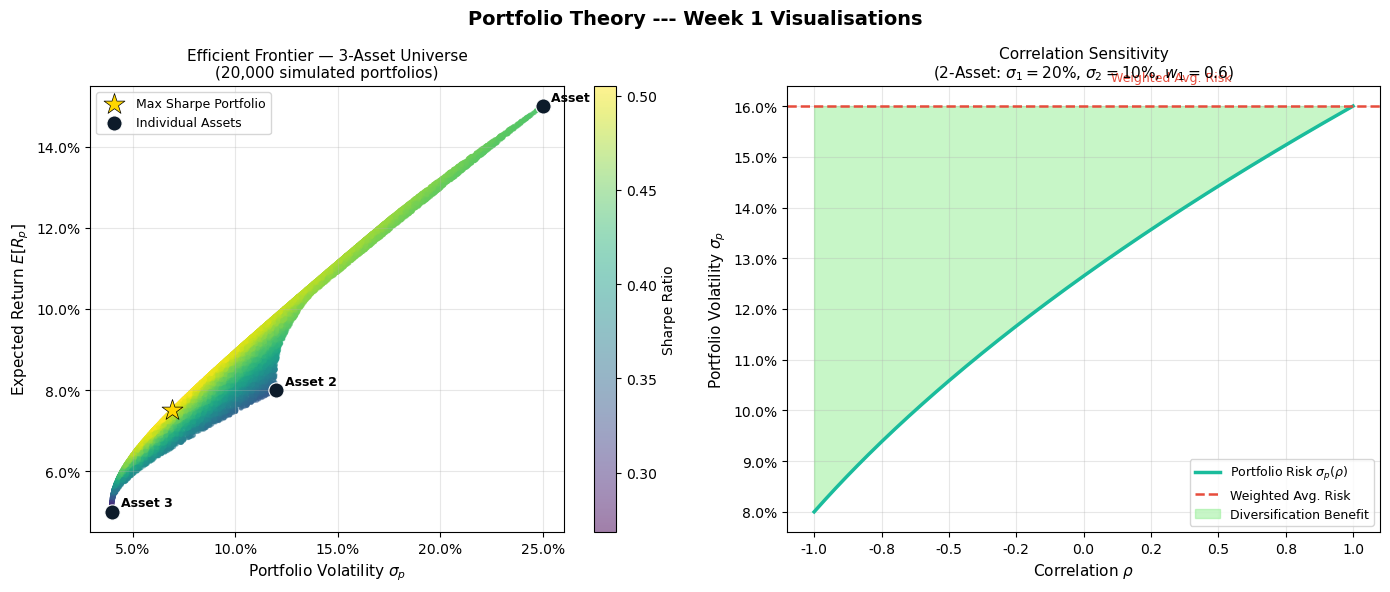

Max Sharpe Ratio : 0.5053
Weights          : [0.1959 0.1802 0.6239]
E[Rp]            : 7.50%  |  σp: 6.93%


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

np.random.seed(42)

# --- 3-Asset universe (Q6/Q11 parameters) ---
mu3    = np.array([0.15, 0.08, 0.05])
Sigma3 = np.array([
    [0.0625,  0.0120,  0.0010 ],
    [0.0120,  0.0144,  0.00096],
    [0.0010,  0.00096, 0.0016 ]
])
Rf = 0.04
tickers = ['Asset 1', 'Asset 2', 'Asset 3']
sig_assets = np.sqrt(np.diag(Sigma3))

# Simulate 20,000 random portfolios
N_sim = 20_000
W = np.random.dirichlet(np.ones(3), size=N_sim)
E_rp  = W @ mu3
sig_p = np.sqrt(np.einsum('ij,jk,ik->i', W, Sigma3, W))
SR    = (E_rp - Rf) / sig_p
best  = np.argmax(SR)

# --- 2-Asset sensitivity (Q12 parameters) ---
mu1_2, sig1_2 = 0.12, 0.20
mu2_2, sig2_2 = 0.06, 0.10
w1_2, w2_2    = 0.6, 0.4
rho_arr        = np.linspace(-1, 1, 200)
sig_p2         = np.sqrt((w1_2*sig1_2)**2 + (w2_2*sig2_2)**2
                          + 2*w1_2*w2_2*rho_arr*sig1_2*sig2_2)
wtd_avg_risk   = w1_2*sig1_2 + w2_2*sig2_2

# ─────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Portfolio Theory --- Week 1 Visualisations',
             fontsize=14, fontweight='bold')

# ── Subplot 1: Efficient Frontier scatter ──────────────────────
sc = ax1.scatter(sig_p, E_rp, c=SR, cmap='viridis',
                 s=6, alpha=0.5, zorder=1)
cbar = fig.colorbar(sc, ax=ax1)
cbar.set_label('Sharpe Ratio', fontsize=10)

# Max Sharpe star
ax1.scatter(sig_p[best], E_rp[best],
            marker='*', s=250, color='gold',
            edgecolors='black', linewidths=0.5,
            zorder=5, label='Max Sharpe Portfolio')

# Individual assets
ax1.scatter(sig_assets, mu3,
            marker='o', s=120, color='#0D1B2A',
            edgecolors='white', linewidths=0.8,
            zorder=4, label='Individual Assets')

for i, (x, y, t) in enumerate(zip(sig_assets, mu3, tickers)):
    ax1.annotate(t, (x, y), textcoords='offset points',
                 xytext=(6, 4), fontsize=9, fontweight='bold')

ax1.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax1.set_xlabel('Portfolio Volatility $\\sigma_p$', fontsize=11)
ax1.set_ylabel('Expected Return $E[R_p]$', fontsize=11)
ax1.set_title('Efficient Frontier — 3-Asset Universe\n(20,000 simulated portfolios)', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# ── Subplot 2: Correlation Sensitivity ────────────────────────
ax2.plot(rho_arr, sig_p2, color='#1ABC9C', lw=2.5,
         label='Portfolio Risk $\\sigma_p(\\rho)$')

ax2.axhline(wtd_avg_risk, color='#E74C3C', lw=1.8,
            linestyle='--', label='Weighted Avg. Risk')
ax2.annotate('Weighted Avg. Risk', xy=(0.5, wtd_avg_risk),
             xytext=(0.1, wtd_avg_risk + 0.005),
             fontsize=9, color='#E74C3C')

# Shade diversification benefit region
ax2.fill_between(rho_arr, sig_p2, wtd_avg_risk,
                 where=(sig_p2 < wtd_avg_risk),
                 color='lightgreen', alpha=0.5,
                 label='Diversification Benefit')

ax2.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f'))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax2.set_xlabel('Correlation $\\rho$', fontsize=11)
ax2.set_ylabel('Portfolio Volatility $\\sigma_p$', fontsize=11)
ax2.set_title('Correlation Sensitivity\n(2-Asset: $\\sigma_1=20\\%$, $\\sigma_2=10\\%$, $w_1=0.6$)', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('week1_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary output ────────────────────────────────────────────
print(f"Max Sharpe Ratio : {SR[best]:.4f}")
print(f"Weights          : {np.round(W[best], 4)}")
print(f"E[Rp]            : {E_rp[best]:.2%}  |  σp: {sig_p[best]:.2%}")